# Librairies

In [4]:
import numpy as np
import matplotlib.pyplot as plt 
import calcul_temps_multiplication as time_multiplication
import functions

NB_ITERATIONS= 5000
Compiling C++ code...
Compilation successful.

Iteration   1/5000 â€” 0.164282 s
Iteration   2/5000 â€” 0.006757 s
Iteration   3/5000 â€” 0.006917 s
Iteration   4/5000 â€” 0.006780 s
Iteration   5/5000 â€” 0.006733 s
Iteration   6/5000 â€” 0.006826 s
Iteration   7/5000 â€” 0.006707 s
Iteration   8/5000 â€” 0.006824 s
Iteration   9/5000 â€” 0.006968 s
Iteration  10/5000 â€” 0.009563 s
Iteration  11/5000 â€” 0.007447 s
Iteration  12/5000 â€” 0.007404 s
Iteration  13/5000 â€” 0.007436 s
Iteration  14/5000 â€” 0.007406 s
Iteration  15/5000 â€” 0.007218 s
Iteration  16/5000 â€” 0.007095 s
Iteration  17/5000 â€” 0.007457 s
Iteration  18/5000 â€” 0.007104 s
Iteration  19/5000 â€” 0.006659 s
Iteration  20/5000 â€” 0.007081 s
Iteration  21/5000 â€” 0.006774 s
Iteration  22/5000 â€” 0.006983 s
Iteration  23/5000 â€” 0.006734 s
Iteration  24/5000 â€” 0.006728 s
Iteration  25/5000 â€” 0.006665 s
Iteration  26/5000 â€” 0.006742 s
Iteration  27/5000 â€” 0.007156 s
Iteration  28/5

# Product Results

## Q1, Q2, Q3, Min, Max

In [5]:
Q1 = time_multiplication.Q1
Q2 = time_multiplication.Q2
Q3 = time_multiplication.Q3
Max = time_multiplication.Max
Min = time_multiplication.Min
times = time_multiplication.times
NB_ITERATIONS = time_multiplication.NB_ITERATIONS

## Histo

C:\Users\pierr\AppData\Local\Temp\ipykernel_39760\1925403877.py:12: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, Max+0.05)


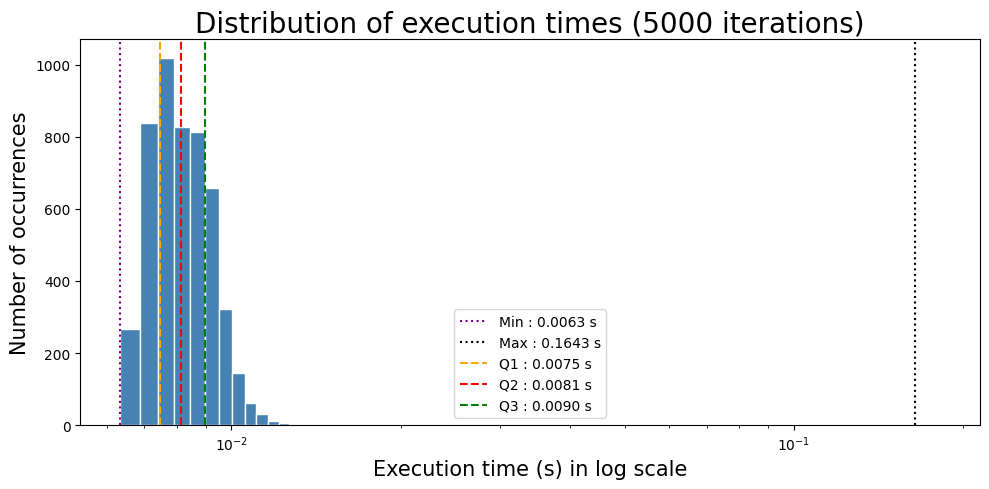

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(times, bins= 300, color="steelblue", edgecolor="white")
ax.axvline(Min, color="purple", linestyle=":",  linewidth=1.5, label=f"Min : {Min:.4f} s")
ax.axvline(Max, color="black",  linestyle=":",  linewidth=1.5, label=f"Max : {Max:.4f} s")
ax.axvline(Q1, color="orange", linestyle="--", linewidth=1.5, label=f"Q1 : {Q1:.4f} s")
ax.axvline(Q2, color="red",    linestyle="--", linewidth=1.5, label=f"Q2 : {Q2:.4f} s")
ax.axvline(Q3, color="green",  linestyle="--", linewidth=1.5, label=f"Q3 : {Q3:.4f} s")
ax.set_xscale("log")
ax.set_xlabel("Execution time (s) in log scale", fontsize=15)
ax.set_ylabel("Number of occurrences", fontsize=15)
ax.set_title(f"Distribution of execution times ({NB_ITERATIONS} iterations)", fontsize=20)
ax.set_xlim(0, Max+0.05)
ax.legend()
plt.tight_layout()
plt.savefig("histogram_execution_times.png", dpi=300)
plt.show()

# Scheduability

## Initial Data

In [ ]:
C1 = int(np.ceil(Max*10)) #to have something with the same order of magnitude

M = np.array([[C1, 10],
              [3, 10],
              [2, 20],
              [2, 20],
              [2, 40],
              [2, 40],
              [3, 80]])

n,m = np.shape(M)
tasks = np.linspace(1,n,n)
C = tuple(M[:,0])
T_i = tuple(M[:,1])

## Round Robin

In [5]:
possibilite_rr, schedule_matrix_rr, waiting_time_rr, string_rr = functions.round_robin(tasks, C, T_i)
string_rr

'J11 J21 J31 J41 J51 J61 J71 J12 J22 -- J32 J42 J13 J23 -- J14 J24 -- J33 J43 J52 J62 J15 J25 J16 J26 -- J34 J44 J17 J27 -- J18 J28 --'

## Rate Monotonic

In [6]:
possibilite_tt, schedule_matrix_tt, waiting_time_tt, string_tt = functions.rate_monotonic(tasks, C, T_i)
string_tt

Rate Monotonic: NOT schedulable


## Earliest Deadline First

In [7]:
possibilite_edf, schedule_matrix_edf, waiting_time_edf, string_edf = functions.earliest_deadline_first(tasks, C, T_i)
string_edf

'J11 J21 J31 J41 J51 J12 J22 J61 J71 -- J13 J23 J32 J42 -- J14 J24 -- J15 J25 J33 J43 J52 J16 J26 J62 -- J17 J27 J34 J44 -- J18 J28 --'